# Experiment
A CatBoost classifier was trained using different feature combinations. To address class imbalance, one of the strategies applied was reformulating the original multiclass problem into a binary classification task.

## Setup
| Parameter                              | Value    |
| -------------------------------------- | -------- |
| Model                                  | CatBoost |
| Iterations                             | 1500     |
| Learning rate                          | 0.025    |
| Depth                                  | 8        |
| L2 leaf regularization (`l2_leaf_reg`) | 5        |
| Loss function                          | Logloss  |
| Scale positive weight                  | N0/N1    |
| Random seed                            | 42       |
| Early stopping rounds                  | 100      |
| Verbose                                | 100      |


## Binary Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


df = pd.read_csv("path/to/data.csv/")

# 1. remap FIRST
df['label'] = df['label'].map({0.0: 0, 1.0: 1, 2.0: 1})

# 2. build shift key
df['shift_key'] = (
    df['ID'].astype(str) + '_' +
    df['date'].astype(str) + '_' +
    df['shift_code'].astype(str)
)

# 3. shift-level split with stratification (avoid data leakage)
shift_info         = df.groupby('shift_key')['label'].agg(lambda x: x.mode()[0])
unique_shifts      = shift_info.index.to_numpy()
shift_label_values = shift_info.values

train_shifts, test_shifts = train_test_split(
    unique_shifts,
    test_size=0.2,
    random_state=42,
    stratify=shift_label_values
)

train_mask = df['shift_key'].isin(train_shifts)
test_mask  = df['shift_key'].isin(test_shifts)

#drop_cols = ["label", "date", "start_datetime", "end_datetime", "ID", "shift_key"]
#X = df.drop(columns=drop_cols)
#y = df["label"]
feature_cols = ["hr", "temp"]

X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")

# 4. class weight (addressing class imbalance)
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("\npos_weight:", round(pos_weight, 3))

# 5. model
cat_features = ["day", "shift_code", "start"]
for col in cat_features:
    df[col] = df[col].astype(str)

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.025,
    depth=8,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=pos_weight,
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64

pos_weight: 1.938
0:	test: 0.5524096	best: 0.5524096 (0)	total: 148ms	remaining: 3m 41s
100:	test: 0.5539485	best: 0.5580757 (5)	total: 756ms	remaining: 10.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5580757388
bestIteration = 5

Shrink model to first 6 iterations.
Macro F1:    0.5332873741799145
Weighted F1: 0.5686689656654828
AUC:         0.5580757388078702

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.55      0.63      2309
           1       0.36      0.55      0.44      1058

    accuracy                           0.55      3367
   macro avg       0.55      0.55      0.53      3367
weighted avg       0.61      0.55      0.57      3367



HR and BT, without context, are insufficient to detect nurse stress alone. This motivates the multimodal approach.

In [10]:
cat_features = ["day", "shift_code", "start", "ID"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["hr", "temp","day", "shift_code", "start", "ID"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
0:	test: 0.7174662	best: 0.7174662 (0)	total: 58.2ms	remaining: 1m 27s
100:	test: 0.8281378	best: 0.8302676 (97)	total: 4.67s	remaining: 1m 4s
200:	test: 0.8264279	best: 0.8302823 (170)	total: 9.73s	remaining: 1m 2s
300:	test: 0.8325166	best: 0.8359878 (287)	total: 14.8s	remaining: 58.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8359878048
bestIteration = 287

Shrink model to first 288 iterations.
Macro F1:    0.68921079475484
Weighted F1: 0.7187392110014902
AUC:         0.8359878047682243

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.70      0.77      2309
           1       0.53      0.72      0.61      1058

    accuracy                           0.71      3367
   macro avg       0

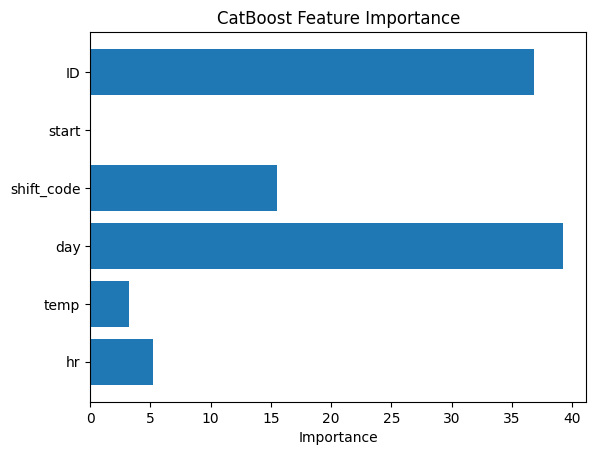

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

In [15]:
cat_features = ["day", "shift_code", "start"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["hr", "temp","day", "shift_code", "start"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
Macro F1:    0.6278489426969537
Weighted F1: 0.6701066284193025
AUC:         0.6794764630225607

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.71      0.74      2309
           1       0.47      0.57      0.51      1058

    accuracy                           0.66      3367
   macro avg       0.63      0.64      0.63      3367
weighted avg       0.68      0.66      0.67      3367



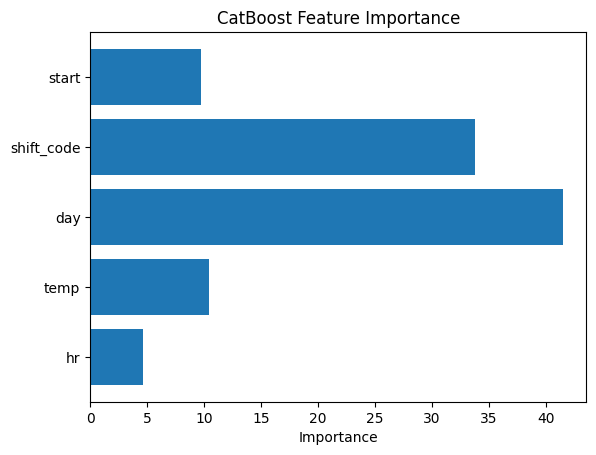

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

In [30]:
cat_features = ["shift_code", "start"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["hr", "temp","shift_code", "start"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
Macro F1:    0.579783700208929
Weighted F1: 0.6206363169390018
AUC:         0.613231613616808

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.63      0.69      2309
           1       0.41      0.55      0.47      1058

    accuracy                           0.61      3367
   macro avg       0.58      0.59      0.58      3367
weighted avg       0.65      0.61      0.62      3367



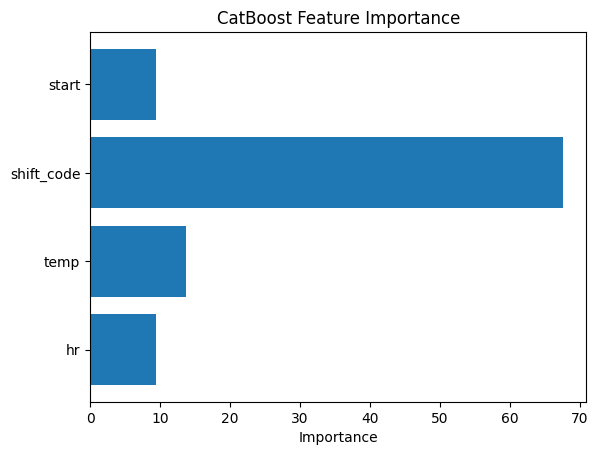

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

In [3]:
cat_features = ["day", "shift_code", "start", "ID"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["day", "shift_code", "start", "ID"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
0:	test: 0.7341391	best: 0.7341391 (0)	total: 36.3ms	remaining: 54.4s
100:	test: 0.8028701	best: 0.8250182 (18)	total: 4.85s	remaining: 1m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8250181545
bestIteration = 18

Shrink model to first 19 iterations.
Macro F1:    0.6220289660469764
Weighted F1: 0.643092002225793
AUC:         0.8250181544887639

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.57      0.68      2309
           1       0.45      0.76      0.57      1058

    accuracy                           0.63      3367
   macro avg       0.64      0.67      0.62      3367
weighted avg       0.72      0.63      0.64      3367



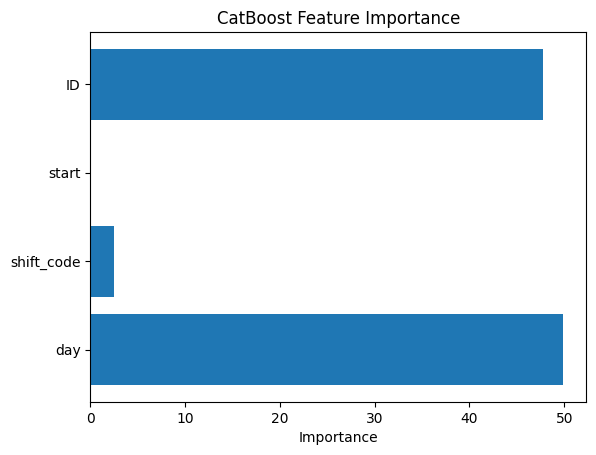

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

In [2]:
cat_features = ["day", "shift_code", "ID"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["hr", "temp", "day", "shift_code", "ID"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
0:	test: 0.6595626	best: 0.6595626 (0)	total: 24.9ms	remaining: 37.3s
100:	test: 0.8124963	best: 0.8136469 (71)	total: 4.22s	remaining: 58.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8136469359
bestIteration = 71

Shrink model to first 72 iterations.
Macro F1:    0.6962634765913455
Weighted F1: 0.7347077371889069
AUC:         0.8136469359234556

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2309
           1       0.57      0.62      0.59      1058

    accuracy                           0.73      3367
   macro avg       0.69      0.70      0.70      3367
weighted avg       0.74      0.73      0.73      3367



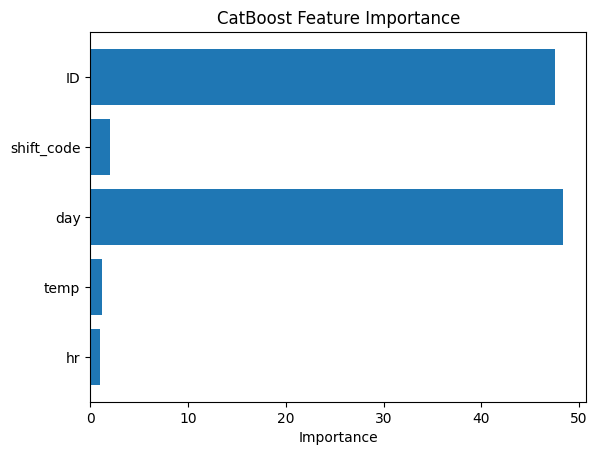

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

In [25]:
cat_features = ["day", "shift_code"]
for col in cat_features:
    df[col] = df[col].astype(str)

feature_cols = ["temp", "day", "shift_code"]


X = df[feature_cols]
y = df["label"]

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

assert len(set(train_shifts) & set(test_shifts)) == 0, "Shift leakage detected!"

print(f"Train: {len(train_shifts)} shifts, {len(X_train)} rows")
print(f"Test:  {len(test_shifts)} shifts, {len(X_test)} rows")
print(f"\nTrain label dist:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  label dist:\n{y_test.value_counts(normalize=True).round(3)}")


cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test, cat_features=cat_feature_indices)

model.fit(train_pool, eval_set=test_pool)

# 6. evaluation
y_test_str = y_test.astype(str)
preds_str  = model.predict(test_pool).astype(str).flatten()
proba      = model.predict_proba(test_pool)[:, 1]

print("Macro F1:   ", f1_score(y_test_str, preds_str, average='macro'))
print("Weighted F1:", f1_score(y_test_str, preds_str, average='weighted'))
print("AUC:        ", roc_auc_score(y_test_str, proba))
print("\nClassification Report:\n")
print(classification_report(y_test_str, preds_str))

Train: 283 shifts, 13445 rows
Test:  71 shifts, 3367 rows

Train label dist:
label
0    0.66
1    0.34
Name: proportion, dtype: float64
Test  label dist:
label
0    0.686
1    0.314
Name: proportion, dtype: float64
0:	test: 0.6600462	best: 0.6600462 (0)	total: 33.7ms	remaining: 50.6s
100:	test: 0.6708520	best: 0.6708520 (100)	total: 4.87s	remaining: 1m 7s
200:	test: 0.6754303	best: 0.6794544 (160)	total: 9.56s	remaining: 1m 1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6794543583
bestIteration = 160

Shrink model to first 161 iterations.
Macro F1:    0.6292027474729647
Weighted F1: 0.6569037988726251
AUC:         0.6794543583462754

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.62      0.70      2309
           1       0.46      0.71      0.55      1058

    accuracy                           0.64      3367
   macro avg       0.64      0.66      0.63      3367
weighted avg       0.71      0.64    

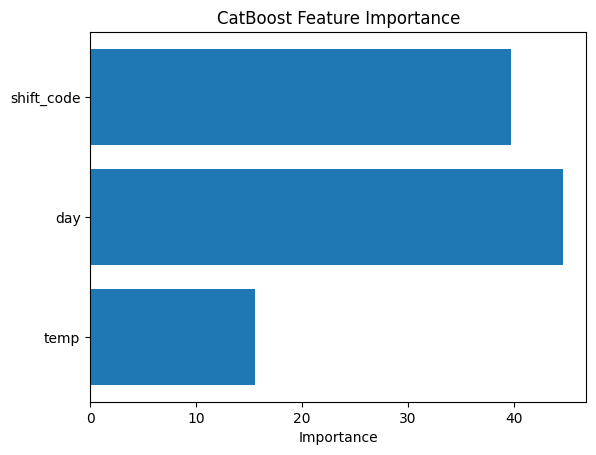

In [ ]:
importances = model.get_feature_importance(train_pool)

feature_names = X_train.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()